In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
import torch.nn.functional as F
from ultralytics import YOLO
from PIL import Image
import collections
import json
import seaborn as sns
import cv2
import sys
import glob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Transformacions i metrica

In [ ]:
KAGGLE_PATH = '/kaggle/input/datasets/xaviertamarit/dataset-1/dataset_reid'
COLAB_PATH = '/content/dataset_reid'
LOCAL_PATH = './dataset_reid'

if 'google.colab' in sys.modules or os.path.exists('/content'):
    DATASET_DIR = COLAB_PATH
    OUTPUT_DIR = '/content'
    print(f" S'ha detectat l'entorn de Google Colab.")
    print(f"Camí de dades actiu: {DATASET_DIR}")
    print(f"Camí de sortida de models (OUTPUT_DIR): {OUTPUT_DIR}")

    if not os.path.exists(COLAB_PATH):
        zip_path = '/content/dataset_reid.zip'
        if os.path.exists(zip_path):
            print("Iniciant la descompressió del dataset...")
            try:
                import zipfile
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall('/content')
                print(" Descompressió completada amb èxit sota l'entorn de Colab.")
            except Exception as e:
                print(f"S'ha produït un error durant la descompressió: {e}")
        else:
            print("No s'ha trobat la carpeta descompressa ni el fitxer 'dataset_reid.zip' a /content.")

elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    DATASET_DIR = KAGGLE_PATH
    OUTPUT_DIR = '/kaggle/working'  # Directori de desat estàndard a Kaggle
    print(f"S'ha detectat l'entorn de Kaggle.")
    print(f"Camí de dades actiu: {DATASET_DIR}")
    print(f"Camí de sortida de models (OUTPUT_DIR): {OUTPUT_DIR}")
else:
    DATASET_DIR = LOCAL_PATH
    OUTPUT_DIR = '.'  # Directori local
    print(f"S'ha detectat l'entorn Local ordinari.")
    print(f"Camí de dades actiu: {DATASET_DIR}")
    print(f"Camí de sortida de models (OUTPUT_DIR): {OUTPUT_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.00035

TRAIN_DIR = os.path.join(DATASET_DIR, 'train')

train_transforms = transforms.Compose([
    fancy_resize := transforms.Resize((256, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Pad(10),
    transforms.RandomCrop((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    num_classes = len(train_dataset.classes)
    print(f" Dataset d'imatges trobat. S'han llistat {num_classes} classes/jugadors diferents.")
except FileNotFoundError:
    num_classes = 1
    train_dataset = None
    train_loader = []
    print(f"No s'ha pogut localitzar la carpeta d'entrenament a: {TRAIN_DIR}")

class TripletLoss(nn.Module):
    """ Triplet loss estàndard dels estudis de Re-ID """
    def __init__(self, margin=0.3):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)

    def forward(self, inputs, targets):
        n = inputs.size(0)
        # Calculem distàncies euclidianes parell a parell
        dist = torch.pow(inputs, 2).sum(dim=1, keepdim=True).expand(n, n)
        dist = dist + dist.t()
        dist.addmm_(inputs, inputs.t(), beta=1, alpha=-2)
        dist = dist.clamp(min=1e-12).sqrt()

        # Cerquem els positius més llunyans (Hard Positive) i negatius més propers (Hard Negative)
        mask = targets.expand(n, n).eq(targets.expand(n, n).t())
        dist_ap, dist_an = [], []
        for i in range(n):
            dist_ap.append(dist[i][mask[i]].max().unsqueeze(0))
            dist_an.append(dist[i][mask[i] == 0].min().unsqueeze(0))
        dist_ap = torch.cat(dist_ap)
        dist_an = torch.cat(dist_an)

        y = torch.ones_like(dist_an)
        loss = self.ranking_loss(dist_an, dist_ap, y)
        return loss


 S'ha detectat l'entorn de Google Colab.
Camí de dades actiu: /content/dataset_reid
Camí de sortida de models (OUTPUT_DIR): /content
Iniciant la descompressió del dataset...
 Descompressió completada amb èxit sota l'entorn de Colab.
 Dataset d'imatges trobat. S'han llistat 21 classes/jugadors diferents.


## Arqutectura

In [ ]:
class ResNet50ReID(nn.Module):
    """ Arquitectura ResNet50 modificada amb canvi de Stride i BNNeck """
    def __init__(self, num_classes):
        super(ResNet50ReID, self).__init__()
        resnet = models.resnet50(pretrained=True)

        # Modificació crítica del stride de la layer4 per evitar pèrdues de resolució espacial
        resnet.layer4[0].conv2.stride = (1, 1)
        resnet.layer4[0].downsample[0].stride = (1, 1)

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)

        # BNNeck per equilibrar les forces de Triplet i Cross-Entropy loss
        self.bottleneck = nn.BatchNorm1d(2048)
        self.bottleneck.bias.requires_grad = False
        self.classifier = nn.Linear(2048, num_classes, bias=False)

    def forward(self, x):
        features_map = self.backbone(x)
        features = self.gap(features_map)
        features = features.view(features.size(0), -1)

        features_bn = self.bottleneck(features)

        if self.training:
            output_class = self.classifier(features_bn)
            return output_class, features
        return features_bn

model = ResNet50ReID(num_classes=num_classes)
model = model.to(device)

criterion_id = nn.CrossEntropyLoss()
criterion_triplet = TripletLoss(margin=0.3)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)

print("\n" + "="*50)
print("INICIANT EL PROCEDIMENT D'APRENENTATGE EN CALENT (RE-ID)")
print("="*50)

if len(train_loader) > 0:
    for epoch in range(EPOCHS):
        model.train()
        loss_id_total = 0.0
        loss_tri_total = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs_class, features = model(inputs)

            loss_id = criterion_id(outputs_class, labels)
            loss_tri = criterion_triplet(features, labels)

            loss_total = loss_id + loss_tri

            loss_total.backward()
            optimizer.step()

            loss_id_total += loss_id.item()
            loss_tri_total += loss_tri.item()

        print(f"Epoch {epoch+1:02d}/{EPOCHS} -> Id Loss: {loss_id_total/len(train_loader):.4f} | Triplet Loss: {loss_tri_total/len(train_loader):.4f}")

    nom_model_final = 'model_reid_lleida_final.pth'
    ruta_guardat_final = os.path.join(OUTPUT_DIR, nom_model_final)

    torch.save({
        'model_state_dict': model.state_dict(),
        'classes': train_dataset.classes
    }, ruta_guardat_final)

    print("\n" + "="*50)
    print(f"El model s'ha desat correctament sota el teu entorn actual!")
    print(f"Ruta absoluta de destí: {ruta_guardat_final}")
    print("="*50)
else:
    print("El DataLoader es buit o el camí és invàlid. Comprova els missatges d'error anteriors.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]



INICIANT EL PROCEDIMENT D'APRENENTATGE EN CALENT (RE-ID)
Epoch 01/20 -> Id Loss: 2.2099 | Triplet Loss: 1.4558
Epoch 02/20 -> Id Loss: 0.8423 | Triplet Loss: 1.1943
Epoch 03/20 -> Id Loss: 0.3498 | Triplet Loss: 0.5966
Epoch 04/20 -> Id Loss: 0.1730 | Triplet Loss: 0.3562
Epoch 05/20 -> Id Loss: 0.1089 | Triplet Loss: 0.2000
Epoch 06/20 -> Id Loss: 0.0648 | Triplet Loss: 0.1297
Epoch 07/20 -> Id Loss: 0.0456 | Triplet Loss: 0.0721
Epoch 08/20 -> Id Loss: 0.0227 | Triplet Loss: 0.0546
Epoch 09/20 -> Id Loss: 0.0314 | Triplet Loss: 0.0721
Epoch 10/20 -> Id Loss: 0.0349 | Triplet Loss: 0.0921
Epoch 11/20 -> Id Loss: 0.0340 | Triplet Loss: 0.0274
Epoch 12/20 -> Id Loss: 0.0443 | Triplet Loss: 0.0454
Epoch 13/20 -> Id Loss: 0.0306 | Triplet Loss: 0.0345
Epoch 14/20 -> Id Loss: 0.0209 | Triplet Loss: 0.0369
Epoch 15/20 -> Id Loss: 0.0122 | Triplet Loss: 0.0147
Epoch 16/20 -> Id Loss: 0.0229 | Triplet Loss: 0.0061
Epoch 17/20 -> Id Loss: 0.0174 | Triplet Loss: 0.0319
Epoch 18/20 -> Id Loss: 

## Entrenament del dataset

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.00035

TRAIN_DIR = os.path.join(DATASET_DIR, 'train')

train_transforms = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Pad(10),
    transforms.RandomCrop((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    num_classes = len(train_dataset.classes)
    print(f"Dataset d'imatges trobat. S'han llistat {num_classes} classes/jugadors diferents.")
except FileNotFoundError:
    num_classes = 10  # Valor per defecte d'inicialització
    train_dataset = None
    train_loader = []
    print(f"No s'ha pogut localitzar la carpeta d'entrenament a: {TRAIN_DIR}")
    print("Verifica que el dataset estigui correctament descomprimit al teu entorn d'execució.")

class TripletLoss(nn.Module):
    """ Triplet loss estàndard dels estudis de Re-ID """
    def __init__(self, margin=0.3):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.ranking_loss = nn.MarginRankingLoss(margin=margin)

    def forward(self, inputs, targets):
        n = inputs.size(0)
        # Calculem distàncies euclidianes parell a parell
        dist = torch.pow(inputs, 2).sum(dim=1, keepdim=True).expand(n, n)
        dist = dist + dist.t()
        dist.addmm_(inputs, inputs.t(), beta=1, alpha=-2)
        dist = dist.clamp(min=1e-12).sqrt()

        # Cerquem els positius més llunyans (Hard Positive) i negatius més propers (Hard Negative)
        mask = targets.expand(n, n).eq(targets.expand(n, n).t())
        dist_ap, dist_an = [], []
        for i in range(n):
            dist_ap.append(dist[i][mask[i]].max().unsqueeze(0))
            dist_an.append(dist[i][mask[i] == 0].min().unsqueeze(0))
        dist_ap = torch.cat(dist_ap)
        dist_an = torch.cat(dist_an)

        y = torch.ones_like(dist_an)
        loss = self.ranking_loss(dist_an, dist_ap, y)
        return loss

class ResNet50ReID(nn.Module):
    """ Arquitectura ResNet50 modificada amb canvi de Stride i BNNeck (Luo et al., 2019) """
    def __init__(self, num_classes):
        super(ResNet50ReID, self).__init__()
        resnet = models.resnet50(pretrained=True)

        # Modificació crítica del stride de la layer4 per evitar pèrdues de resolució espacial en siluetes petites
        resnet.layer4[0].conv2.stride = (1, 1)
        resnet.layer4[0].downsample[0].stride = (1, 1)

        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.gap = nn.AdaptiveAvgPool2d(1)

        # BNNeck per equilibrar les forces de Triplet i Cross-Entropy loss
        self.bottleneck = nn.BatchNorm1d(2048)
        self.bottleneck.bias.requires_grad = False
        self.classifier = nn.Linear(2048, num_classes, bias=False)

    def forward(self, x):
        features_map = self.backbone(x)
        features = self.gap(features_map)
        features = features.view(features.size(0), -1)

        features_bn = self.bottleneck(features)

        if self.training:
            output_class = self.classifier(features_bn)
            return output_class, features
        return features_bn


model = ResNet50ReID(num_classes=num_classes)
model = model.to(device)

criterion_id = nn.CrossEntropyLoss()
criterion_triplet = TripletLoss(margin=0.3)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)

print("\n" + "="*50)
print("INICIANT EL PROCEDIMENT DE TRAIN (RE-ID)")
print("="*50)

if train_loader and len(train_loader) > 0:
    for epoch in range(EPOCHS):
        model.train()
        loss_id_total = 0.0
        loss_tri_total = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs_class, features = model(inputs)

            loss_id = criterion_id(outputs_class, labels)
            loss_tri = criterion_triplet(features, labels)

            loss_total = loss_id + loss_tri

            loss_total.backward()
            optimizer.step()

            loss_id_total += loss_id.item()
            loss_tri_total += loss_tri.item()

        print(f"Epoch {epoch+1:02d}/{EPOCHS} -> Id Loss: {loss_id_total/len(train_loader):.4f} | Triplet Loss: {loss_tri_total/len(train_loader):.4f}")


    nom_model_final = 'model_reid_lleida_final.pth'
    ruta_guardat_final = os.path.join(OUTPUT_DIR, nom_model_final)

    torch.save({
        'model_state_dict': model.state_dict(),
        'classes': train_dataset.classes
    }, ruta_guardat_final)

    print("\n" + "="*50)
    print(f"El model s'ha desat correctament sota el teu entorn actual!")
    print(f"Ruta absoluta de destí: {ruta_guardat_final}")
    print("="*50)
else:
    print("El DataLoader es buit o el camí és invàlid. Comprova els missatges d'error anteriors.")




Dataset d'imatges trobat. S'han llistat 21 classes/jugadors diferents.

INICIANT EL PROCEDIMENT D'APRENENTATGE EN CALENT (RE-ID)
Epoch 01/20 -> Id Loss: 2.2381 | Triplet Loss: 1.6214
Epoch 02/20 -> Id Loss: 0.8539 | Triplet Loss: 1.1275
Epoch 03/20 -> Id Loss: 0.4215 | Triplet Loss: 0.5383
Epoch 04/20 -> Id Loss: 0.2031 | Triplet Loss: 0.3354
Epoch 05/20 -> Id Loss: 0.1107 | Triplet Loss: 0.2209
Epoch 06/20 -> Id Loss: 0.0608 | Triplet Loss: 0.1468
Epoch 07/20 -> Id Loss: 0.0589 | Triplet Loss: 0.1082
Epoch 08/20 -> Id Loss: 0.0519 | Triplet Loss: 0.0957
Epoch 09/20 -> Id Loss: 0.0365 | Triplet Loss: 0.0417
Epoch 10/20 -> Id Loss: 0.0427 | Triplet Loss: 0.0825
Epoch 11/20 -> Id Loss: 0.0475 | Triplet Loss: 0.0436
Epoch 12/20 -> Id Loss: 0.0206 | Triplet Loss: 0.0096
Epoch 13/20 -> Id Loss: 0.0176 | Triplet Loss: 0.0239
Epoch 14/20 -> Id Loss: 0.0202 | Triplet Loss: 0.0315
Epoch 15/20 -> Id Loss: 0.0136 | Triplet Loss: 0.0168
Epoch 16/20 -> Id Loss: 0.0140 | Triplet Loss: 0.0158
Epoch 1

## Test

In [ ]:
QUERY_DIR = os.path.join(DATASET_DIR, 'test/query')
GALLERY_DIR = os.path.join(DATASET_DIR, 'test/gallery')

test_transforms = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    query_dataset = datasets.ImageFolder(QUERY_DIR, transform=test_transforms)
    gallery_dataset = datasets.ImageFolder(GALLERY_DIR, transform=test_transforms)

    query_loader = DataLoader(query_dataset, batch_size=32, shuffle=False, num_workers=2)
    gallery_loader = DataLoader(gallery_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"\n Carregades {len(query_dataset)} imatges de Query per a l'avaluació.")
    print(f"Carregades {len(gallery_dataset)} imatges de Gallery per a l'avaluació.")

    def select_features(model, dataloader):
        model.eval()
        totes_les_features = []
        totes_les_labels = []

        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                features = model(inputs)
                features = F.normalize(features, p=2, dim=1)

                totes_les_features.append(features.cpu())
                totes_les_labels.append(labels)

        return torch.cat(totes_les_features), torch.cat(totes_les_labels)

    print("\nExtraient vectors de característiques mètrics a la GPU...")
    gallery_features, gallery_labels = select_features(model, gallery_loader)
    query_features, query_labels = select_features(model, query_loader)

    def avaluar_reid(q_feat, q_labels, g_feat, g_labels):
        # Matriu de distàncies euclidianes parell a parell
        dist_matrix = torch.cdist(q_feat, g_feat).numpy()

        rank1_corrects = 0
        aps = []
        num_queries = q_feat.size(0)

        for i in range(num_queries):
            indices_ordenats = np.argsort(dist_matrix[i])
            labels_ordenades = g_labels[indices_ordenats].numpy()
            label_real_query = q_labels[i].item()

            # Rank-1
            if labels_ordenades[0] == label_real_query:
                rank1_corrects += 1

            # Average Precision
            coincidencies = (labels_ordenades == label_real_query).astype(int)
            total_positius = np.sum(coincidencies)

            if total_positius == 0:
                aps.append(0.0)
                continue

            # Formula formal del mAP per rànquing numèric
            intersectats = 0
            sum_precision = 0.0
            for rank_idx, hit in enumerate(coincidencies):
                if hit == 1:
                    intersectats += 1
                    precision_at_k = intersectats / (rank_idx + 1)
                    sum_precision += precision_at_k

            ap = sum_precision / total_positius
            aps.append(ap)

        rank1_accuracy = (rank1_corrects / num_queries) * 100
        map_score = np.mean(aps) * 100

        return rank1_accuracy, map_score

    rank1, mAP = avaluar_reid(query_features, query_labels, gallery_features, gallery_labels)

    print("\n" + "="*50)
    print(" RESULTATS FINALS DEL TEST DE RE-ID:")
    print("="*50)
    print(f" Precisió Rank-1: {rank1:.2f}%")
    print(f" Mean Average Precision (mAP): {mAP:.2f}%")
    print("="*50)

except FileNotFoundError:
    print("\nNo s'ha pogut iniciar l'avaluació de test.")

# Analisi del video

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.7 MB/s eta 0:00:00
[CCMA] Extracting URL: https://www.3cat.cat/3cat/lleida-joventut-lliga-j23/video/6394037/
[CCMA] 6394037: Downloading JSON metadata
[CCMA] 6394037: Downloading MPD manifest
[info] 6394037: Downloading 1 format(s): dash-10feb6f6-ba4c-483f-8caa-b6ec7eafb660+dash-a416bd18-b3f1-42b5-9f56-603901a4b812
[dashsegments] Total fragments: 1786
[download] Destination: partit_lleida_V2.fdash-10feb6f6-ba4c-483f-8caa-b6ec7eafb660.mp4
[download] 100% of    3.24GiB in 00:09:38 at 5.74MiB/s
[dashsegments] Total fragments: 1786
[download] Destination: partit_lleida_V2.fdash-a416bd18-b3f1-42b5-9f56-603901a4b812.m4a
[download] 100% of  108.26MiB in 00:06:05 at 303.43KiB/s
[Merger] Merging formats into "partit_lleida_V2.mp4"
Deleting original file partit_lleida_V2.fdash-10feb6f6-ba4c-483f-8caa-b6ec7eafb660.mp4 (pass -k to keep)
Deleting original file p

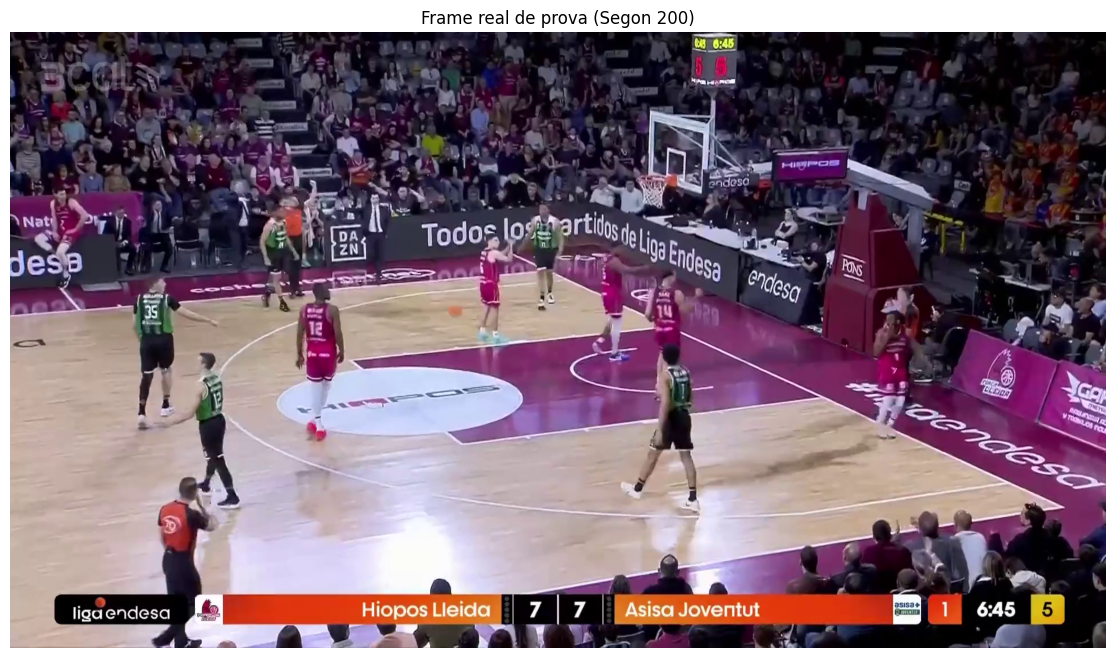

In [ ]:
!pip install -q yt-dlp
!yt-dlp -f "bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4" "https://www.3cat.cat/3cat/lleida-joventut-lliga-j23/video/6394037/" -o "partit_lleida_V2.mp4"


segon_test = 200

cap = cv2.VideoCapture("partit_lleida_V2.mp4")
fps = cap.get(cv2.CAP_PROP_FPS) or 25
cap.set(cv2.CAP_PROP_POS_FRAMES, int(segon_test * fps))

ret, frame_bgr = cap.read()
cap.release()

if ret:
    print(f"\n Fotograma extret correctament del segon {segon_test}.")
    print(f" Resolució: {frame_bgr.shape[1]}x{frame_bgr.shape[0]}")

    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f"Frame real de prova (Segon {segon_test})")
    plt.show()
else:
    print("\n Error: No s'ha pogut llegir el fitxer del vídeo.")

## Inicialització de Plantilles, Models i Pesos

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

llista_lleida = [
    "01_James_Batemon", "02_Corey_Walden", "03_Melvin_Ejim",
    "04_Caleb_Agada", "05_Oriol_Pauli", "06_Dani_Garcia",
    "07_Gyorgy_Goloman", "12_Atoumane_Diagne", "14_Mikel_Sanz",
     "22_John_Shurna", "25_Cameron_Krutwig"
]

llista_joventut = [
    "01_Y_Kraag",
    "09_R_Rubio",
    "11_J_Parker",
    "12_L_Hakanson",
    "23_M_Ruzic",
    "24_C_Hunt",
    "35_S_Birgander",
    "88_A_Hanga"
]


In [ ]:
try:
    from ultralytics import YOLO
except ImportError:
    print("No s'ha trobat 'ultralytics' instal·lat. Instal·lant en calent...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    from ultralytics import YOLO

if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'  # Directori de treball de Google Colab
    print(f"Entorn: Google Colab. Buscant pesos a: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'  # Directori d'escriptura de Kaggle
    print(f" Entorn: Kaggle. Buscant pesos a: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'  # Directori local actual
    print(f"Entorn: Local. Buscant pesos a: {OUTPUT_DIR}")

# Autodetectem si hi ha GPU CUDA activa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Dispositiu de càlcul actiu: {device}")


class ResNet50ReID(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50ReID, self).__init__()
        resnet = models.resnet50(weights=None)
        resnet.layer4[0].conv2.stride = (1, 1)
        resnet.layer4[0].downsample[0].stride = (1, 1)

        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.bottleneck = nn.BatchNorm1d(2048)
        self.bottleneck.bias.requires_grad_(False)
        self.classifier = nn.Linear(2048, num_classes, bias=False)

    def forward(self, x):
        features = self.backbone(x)
        features = self.gap(features)
        features = features.view(features.size(0), -1)
        features_bn = self.bottleneck(features)
        return features_bn

# =========================================================================
# CÀRREGA DELS PESOS .PTH SEGONS L'ENTORN ACTIU
# =========================================================================
ruta_pesos = os.path.join(OUTPUT_DIR, 'model_reid_lleida_final.pth')

if os.path.exists(ruta_pesos):
    checkpoint = torch.load(ruta_pesos, map_location=device)
    noms_classes = checkpoint['classes']
    num_classes = len(noms_classes)

    model_reid = ResNet50ReID(num_classes).to(device)
    model_reid.load_state_dict(checkpoint['model_state_dict'])
    model_reid.eval()
    print(f"Model Re-ID del paper carregat amb èxit ({num_classes} jugadors en total entre Lleida i Joventut).")
else:
    print(f"No s'ha pogut localitzar l'arxiu de pesos a: {ruta_pesos}")

detector_yolo = YOLO('yolov8x.pt')
if device.type == 'cpu':
    detector_yolo.to('cpu')

print("Detector YOLOv8 inicialitzat correctament.")

Entorn: Google Colab. Buscant pesos a: /content
 Dispositiu de càlcul actiu: cuda
Model Re-ID del paper carregat amb èxit (21 jugadors en total entre Lleida i Joventut).
Detector YOLOv8 inicialitzat correctament.


## Preprocessament i Construcció de la Galeria

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms, datasets
import gc

inferencia_transforms = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

GALLERY_DIR = os.path.join(DATASET_DIR, 'test/gallery')

try:
    gallery_dataset = datasets.ImageFolder(GALLERY_DIR, transform=inferencia_transforms)

    galeria_embeddings = []
    galeria_labels = []

    # Neteja preventiva de la VRAM abans d'omplir-la de dades noves
    gc.collect()
    torch.cuda.empty_cache()
    model_reid.eval()

    print("\n Processant la galeria...")

    with torch.no_grad():
        for img, label in gallery_dataset:
            img_t = img.unsqueeze(0).to(device)

            embedding = model_reid(img_t)
            embedding = F.normalize(embedding, p=2, dim=1)

            galeria_embeddings.append(embedding.detach().cpu())
            galeria_labels.append(label)

    galeria_embeddings = torch.cat(galeria_embeddings)

    torch.cuda.empty_cache()

    print(f"Galeria de referència consolidada correctament! Mida de la matriu: {galeria_embeddings.shape}")

except FileNotFoundError:
    print(f"No s'ha pogut trobar la carpeta de galeria d'avaluació a la ruta: {GALLERY_DIR}")


 Processant la galeria...
Galeria de referència consolidada correctament! Mida de la matriu: torch.Size([316, 2048])


## Algoritme de identificació i reidentificació

YOLO ha trobat 11 persones a la pista.


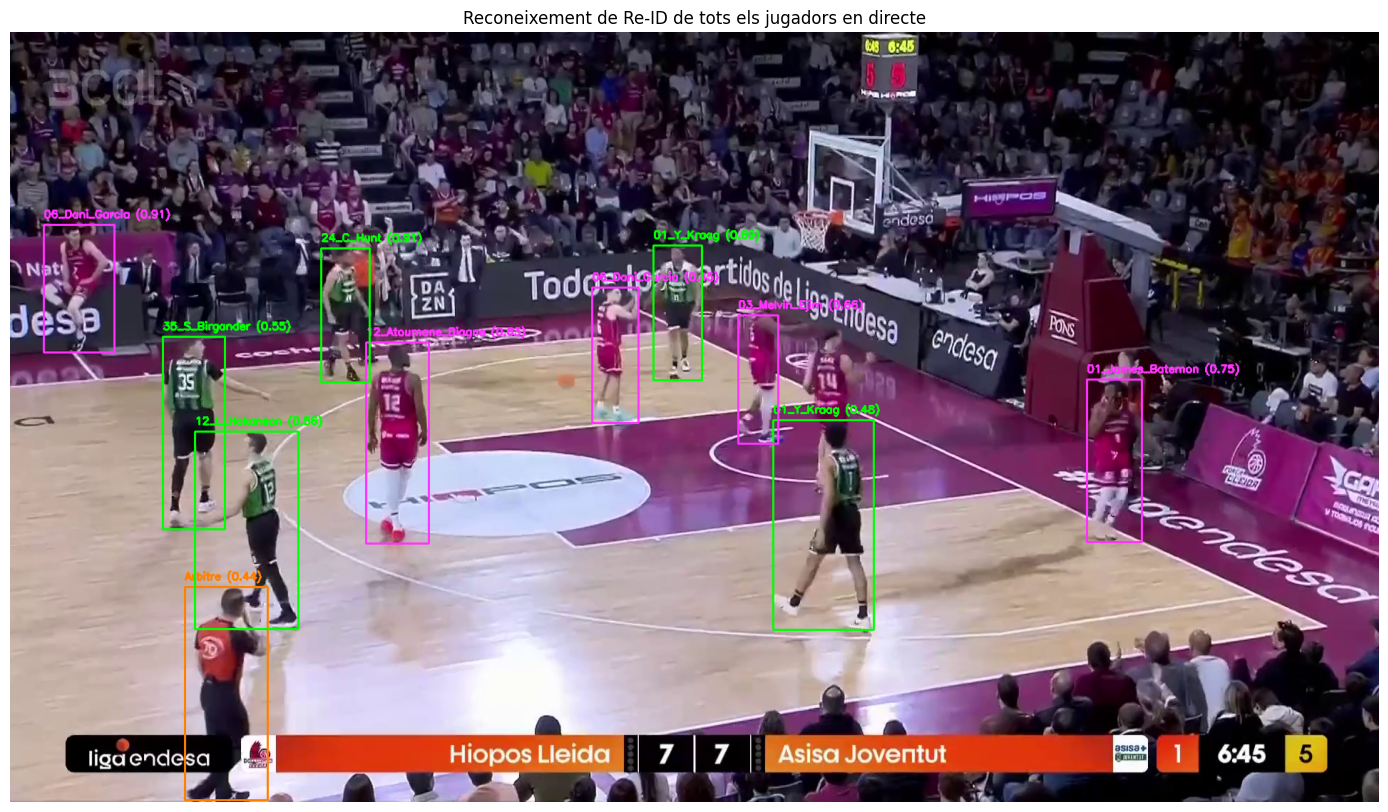

In [ ]:
def processar_frame_test(frame_origen):
    img_dibuixada = frame_origen.copy()

    # YOLO troba totes les siluetes
    dev_type = 'cpu' if device.type == 'cpu' else 0
    results = detector_yolo(frame_origen, classes=0, conf=0.4, verbose=False, device=dev_type)[0]
    print(f"YOLO ha trobat {len(results.boxes)} persones a la pista.")

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        y1, y2 = max(0, y1), min(frame_origen.shape[0], y2)
        x1, x2 = max(0, x1), min(frame_origen.shape[1], x2)

        person_crop = frame_origen[y1:y2, x1:x2]
        if person_crop.size == 0: continue

        img_pil = Image.fromarray(cv2.cvtColor(person_crop, cv2.COLOR_BGR2RGB))
        img_t = inferencia_transforms(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            query_embedding = model_reid(img_t)
            query_embedding = F.normalize(query_embedding, p=2, dim=1).cpu()

        # Cerquem la distancia mes curta dins de tota la base de dades
        distancies = torch.cdist(query_embedding, galeria_embeddings).numpy()[0]
        idx_mes_proper = np.argsort(distancies)[0]
        distancia_minima = distancies[idx_mes_proper]

        # S'obté identitat real
        classe_index_real = galeria_labels[idx_mes_proper]
        nom_jugador = noms_classes[classe_index_real]
        nom_pantalla = nom_jugador.replace('_', ' ')
        label_text = f"{nom_jugador} ({distancia_minima:.2f})"

        if nom_jugador in llista_lleida:
            color_caixa = (255, 50, 255)  # Lila en BGR (Hiopos Lleida)
        elif nom_jugador in llista_joventut:
            color_caixa = (0, 255, 0)    # Verd en BGR (Joventut de Badalona)
        else:
            color_caixa = (0, 128, 255)  # Taronja en BGR

        cv2.rectangle(img_dibuixada, (x1, y1), (x2, y2), color_caixa, 2)
        cv2.putText(img_dibuixada, label_text, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_caixa, 2)

    plt.figure(figsize=(18, 10))
    plt.imshow(cv2.cvtColor(img_dibuixada, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Reconeixement de Re-ID de tots els jugadors en directe")
    plt.show()

processar_frame_test(frame_bgr)

In [ ]:
registre_posicions = {}
for jugador in llista_lleida + llista_joventut:
    registre_posicions[jugador] = []

def avaluar_i_registrar_frame(frame_origen, llindar_min_pct=0.0003, llindar_max_pct=0.04, minim_jugadors=8):
    """
    Avalua el frame i dibuixa els jugadors oficials del Lleida o Joventut per guardarho en un video. Els àrbitres i el public s'ignoren
    """
    alçada, amplada, _ = frame_origen.shape
    area_total_frame = amplada * alçada
    img_render = frame_origen.copy()

    dev_type = 'cpu' if device.type == 'cpu' else 0
    results = detector_yolo(frame_origen, classes=0, conf=0.25, verbose=False, device=dev_type)[0]

    jugadors_valids_trobats = 0
    primer_pla = False

    deteccions_frame_actual = []

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        y1, y2 = max(0, y1), min(alçada, y2)
        x1, x2 = max(0, x1), min(amplada, x2)

        area_retall = (x2 - x1) * (y2 - y1)

        # Filtre de mida mínima
        if area_retall < (area_total_frame * llindar_min_pct):
            continue

        person_crop = frame_origen[y1:y2, x1:x2]
        if person_crop.size == 0:
            continue

        # Executem el Re-ID
        img_pil = Image.fromarray(cv2.cvtColor(person_crop, cv2.COLOR_BGR2RGB))
        img_t = inferencia_transforms(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            query_embedding = model_reid(img_t)
            query_embedding = F.normalize(query_embedding, p=2, dim=1).cpu()

        distancies = torch.cdist(query_embedding, galeria_embeddings).numpy()[0]
        idx_mes_proper = np.argsort(distancies)[0]
        nom_jugador = noms_classes[galeria_labels[idx_mes_proper]]

        es_lleida = nom_jugador in llista_lleida
        es_joventut = nom_jugador in llista_joventut

        # Filtre de mida màxima
        if area_retall > (area_total_frame * llindar_max_pct):
            primer_pla = True

        if es_lleida or es_joventut:
            jugadors_valids_trobats += 1
            color_caixa = (255, 50, 255) if es_lleida else (0, 255, 0)

            # Coordenades dels peus per al mapa de calor
            x_pista = int((x1 + x2) / 2)
            y_pista = int(y2)
            deteccions_frame_actual.append((nom_jugador, (x_pista, y_pista)))

            nom_pantalla = nom_jugador.replace('_', ' ')
            label_text = f"{nom_pantalla} ({distancies[idx_mes_proper]:.2f})"
            cv2.rectangle(img_render, (x1, y1), (x2, y2), color_caixa, 2)
            cv2.putText(img_render, label_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_caixa, 2)
        else:
            continue

    if not primer_pla and jugadors_valids_trobats >= minim_jugadors:
        return True, img_render, deteccions_frame_actual
    else:
        return False, frame_origen, []


In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"[INFO] Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"[INFO] Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"[INFO] Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part1_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors1.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 0
FRAME_FINAL = 7000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval 0-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

[INFO] Entorn: Google Colab. Directori de sortida: /content
 Filtre: Mínim 8 jugadors reals | No àrbitres visuals | Interval 0-7000
--------------------------------------------------------------------------------
 Processant: Frame 0/7000 | Frames nets transcrits: 0
 Processant: Frame 250/7000 | Frames nets transcrits: 2
 Processant: Frame 500/7000 | Frames nets transcrits: 97
 Processant: Frame 750/7000 | Frames nets transcrits: 274
 Processant: Frame 1000/7000 | Frames nets transcrits: 402
 Processant: Frame 1250/7000 | Frames nets transcrits: 572
 Processant: Frame 1500/7000 | Frames nets transcrits: 786
 Processant: Frame 1750/7000 | Frames nets transcrits: 926
 Processant: Frame 2000/7000 | Frames nets transcrits: 1159
 Processant: Frame 2250/7000 | Frames nets transcrits: 1284
 Processant: Frame 2500/7000 | Frames nets transcrits: 1497
 Processant: Frame 2750/7000 | Frames nets transcrits: 1539
 Processant: Frame 3000/7000 | Frames nets transcrits: 1764
 Processant: Frame 3250/70

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part2_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors2.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 7000
FRAME_FINAL = 14000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval 0-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f" Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part3_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors3.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 14000
FRAME_FINAL = 21000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval 0-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"[INFO] Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"[INFO] Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"[INFO] Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part4_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors4.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 21000
FRAME_FINAL = 28000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part5_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors5.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 28000
FRAME_FINAL = 35000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part6_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors6.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 35000
FRAME_FINAL = 42000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part7_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors7.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 42000
FRAME_FINAL = 49000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part8_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors8.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 49000
FRAME_FINAL = 56000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part9_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors9.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 56000
FRAME_FINAL = 63000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part10_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors10.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 63000
FRAME_FINAL = 70000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part11_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors11.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 70000
FRAME_FINAL = 77000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part12_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors12.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 77000
FRAME_FINAL = 84000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f" Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"[INFO] Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part13_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors13.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 84000
FRAME_FINAL = 91000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"[Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part14_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors14.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 91000
FRAME_FINAL = 98000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"[INFO] Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part15_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors15.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 98000
FRAME_FINAL = 105000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part16_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors16.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 105000
FRAME_FINAL = 112000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part17_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors17.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 112000
FRAME_FINAL = 119000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part18_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors18.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 119000
FRAME_FINAL = 126000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part19_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors19.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 126000
FRAME_FINAL = 133000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part20_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors20.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 133000
FRAME_FINAL = 140000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part21_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors21.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 140000
FRAME_FINAL = 147000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part22_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors22.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 147000
FRAME_FINAL = 154000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part23_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors23.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 154000
FRAME_FINAL = 161000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part24_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors24.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 161000
FRAME_FINAL = 168000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part24_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors24.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 168000
FRAME_FINAL = 175000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")

In [ ]:
if 'google.colab' in sys.modules or os.path.exists('/content'):
    OUTPUT_DIR = '/content'
    INPUT_VIDEO_DIR = '/content'
    print(f"Entorn: Google Colab. Directori de sortida: {OUTPUT_DIR}")
elif os.path.exists('/kaggle') or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    OUTPUT_DIR = '/kaggle/working'
    INPUT_VIDEO_DIR = '/kaggle/working'
    print(f"Entorn: Kaggle. Directori de sortida: {OUTPUT_DIR}")
else:
    OUTPUT_DIR = '.'
    INPUT_VIDEO_DIR = '.'
    print(f"Entorn: Local. Directori de sortida: {OUTPUT_DIR}")

RUTA_VIDEO_SORTIDA = os.path.join(OUTPUT_DIR, 'partit_filtrat_part25_net.mp4')
ruta_json_sortida = os.path.join(OUTPUT_DIR, 'posicions_jugadors25.json')

ruta_entrada_original = 'partit_lleida_V2.mp4'
ruta_entrada_entorn = os.path.join(INPUT_VIDEO_DIR, 'partit_lleida_V2.mp4')

if os.path.exists(ruta_entrada_entorn):
    ruta_entrada = ruta_entrada_entorn
else:
    ruta_entrada = ruta_entrada_original

cap = cv2.VideoCapture(ruta_entrada)

fps = int(cap.get(cv2.CAP_PROP_FPS)) if cap.get(cv2.CAP_PROP_FPS) > 0 else 25
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(RUTA_VIDEO_SORTIDA, fourcc, fps, (width, height))

FRAME_INICI = 175000
FRAME_FINAL = 182000

cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_INICI)

frames_guardats_comptador = 0
frame_actual = FRAME_INICI

if 'registre_posicions' not in locals() and 'registre_posicions' not in globals():
    registre_posicions = collections.defaultdict(list)

print(f" Filtre: Mínim {8} jugadors reals | No àrbitres visuals | Interval {FRAME_INICI}-{FRAME_FINAL}")
print("-" * 80)

while cap.isOpened() and frame_actual <= FRAME_FINAL:
    ret, frame = cap.read()
    if not ret:
        print(" No s'ha pogut llegir el frame o s'ha arribat al final del vídeo.")
        break

    es_valid, frame_processat, deteccions_valides = avaluar_i_registrar_frame(
        frame,
        llindar_min_pct=0.0003,
        llindar_max_pct=0.04,
        minim_jugadors=8
    )

    if es_valid:
        out.write(frame_processat)
        frames_guardats_comptador += 1
        for jugador_id, coordenades in deteccions_valides:
            registre_posicions[jugador_id].append(coordenades)

    if frame_actual % 250 == 0:
        print(f" Processant: Frame {frame_actual}/{FRAME_FINAL} | Frames nets transcrits: {frames_guardats_comptador}")

    frame_actual += 1

cap.release()
out.release()

with open(ruta_json_sortida, 'w') as f:
    json.dump(registre_posicions, f)

print("-" * 80)
print(f" Vídeo net desat a: {RUTA_VIDEO_SORTIDA}")
print(f" Posicions desades a: {ruta_json_sortida}")